# Preprocess Annotated Annotated Data
Translate Label Studio JSON files to a format for ML & split into an 80/20 train/test split.

In [163]:
%pip install iterative-stratification

13325.46s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [164]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [165]:
ANNOTATED_DATA_JSON_PATH = "../data/input/annotated-1150-at-12-06-26.json"
TAXONOMY_PATH = "../data/output/taxonomy_autogen.csv"
TRAIN_OUTPUT_PATH = "../data/output/train_data_{0}.json"
TEST_OUTPUT_PATH = "../data/output/test_data_{0}.json"

RANDOM_STATE = 42

## Import from JSON file

In [166]:
with open(ANNOTATED_DATA_JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

1151

In [167]:
# Loop through each task, extract fields we want, get rid of extra metadata (e.g. updated at, annotation ids, etc.)
records = []

for task in data:
    id = task['data']['id']
    text = task['data']['note_content']
    
    # Extract annotations
    task_annotations = task['annotations']
    if len(task_annotations) == 0:
        # No annotations
        continue
    elif len(task_annotations) > 1:
        # I accidentally converted some gemini predictions into 'annotations' by. There's no easy way to undo this in label studio, so we manually filter here.
        first_annotation = min(task_annotations, key=lambda x: datetime.strptime(x['created_at'], "%Y-%m-%dT%H:%M:%S.%fZ"))
        annotations = first_annotation['result']
    else:
        annotations = task_annotations[0]['result']
    
    # Extract labels & relations
    needs = []
    entities = []
    relations = []
    
    for ann in annotations:
        # Links
        if ann['type'] == 'relation':
            relations.append({
                "from": ann['from_id'],
                "to": ann['to_id']
            })
        # Additional Needs
        elif ann['from_name'] == 'need_labels':
            for label in ann['value']['labels']: # Handles if the same span has multiple labels
                needs.append({
                    "id": ann['id'],
                    "start": ann['value']['start'],
                    "end": ann['value']['end'],
                    "label": label
                })
        # Entities (Person Name, Person Role, Person Pronoun)
        elif ann['from_name'] == 'entity_labels':
            for label in ann['value']['labels']: # Handles if the same span has multiple labels
                entities.append({
                    "id": ann['id'],
                    "start": ann['value']['start'],
                    "end": ann['value']['end'],
                    "label": label
                })
        else:
            print(f"Error processing note id: {id}, annotation: {ann}")
            
    records.append({
        "id": id,
        "text": text,
        "needs": needs,
        "entities": entities,
        "relations": relations
    })

len(records)

1151

In [168]:
records[1]

{'id': '685524bb-94d4-4f08-8669-0e78df744c0c',
 'text': '[Category: tenureManagement] Welfare check and tenancy audit completed I visited the tenant in his property following his request for me to come over and assess the toilet in his property. I used the opportunity to complete a tenancy audit and I observed that he is a hoarder with so many items in nearly all the rooms. The toilet seat has broken and the toilet is as dark as charcoal.',
 'needs': [{'id': '3aefb716',
   'start': 268,
   'end': 275,
   'label': 'housing_conditions_hoarding'},
  {'id': '99751da7',
   'start': 281,
   'end': 318,
   'label': 'housing_conditions_hoarding'},
  {'id': '354b3b37',
   'start': 324,
   'end': 346,
   'label': 'property_level_disrepair_damp_mould'},
  {'id': 'c8515bee',
   'start': 355,
   'end': 384,
   'label': 'cautions_unclean_unsafe_living_environment'}],
 'entities': [{'id': '2373321f',
   'start': 85,
   'end': 91,
   'label': 'Person_Role'}],
 'relations': [{'from': '3aefb716', 'to': 

## Create Binary Label Matrix

In [169]:
taxonomy = pd.read_csv(TAXONOMY_PATH)
taxonomy.head(5)

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"['Care leaver', 'Care experienced (under 25)']",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


In [170]:
def make_binary_label_matrix(raw_data, taxonomy_df):
    cat_labels = taxonomy_df['cat_label'].tolist()
    matrix_rows = []
    
    for record in raw_data:
        unique_labels = set(need['label'] for need in record.get('needs', [])) 
        
        row = {cat: (1 if cat in unique_labels else 0) for cat in cat_labels}
        matrix_rows.append(row)
        
    df_cats = pd.DataFrame(matrix_rows)
    
    # Rename columns to human-readable descriptions based on taxonomy
    cat_to_label = taxonomy_df.set_index('cat_label')['category_description'].to_dict()
    df_cats = df_cats.rename(columns=cat_to_label)
    
    return df_cats

df_labels = make_binary_label_matrix(records, taxonomy)
df_labels.head()

,Care experienced,Care setting,Has caring responsibility,Social care involvement,ASBO or injunction obtained,Dangerous Animals,Physical Abuse or Threat of,Unclean / Unsafe Living Environment,Verbal Abuse or Threat of,Communication needs,...,Mobility - physical,Service need,Property adapted,"Disrepair, damp & mould",Infestation,Anti-Social Behaviour,Domestic abuse,Fire-related risks,Gas Capped,Risk of exploitation
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


## Analyse distribution

,label,IRLbl
0,Medical Condition,1.000000
1,"Disrepair, damp & mould",1.017964
2,Anti-Social Behaviour,1.069182
3,Social care involvement,1.634615
4,Care setting,1.789474
5,Temporary,1.868132
6,Mental Health,2.000000
7,Mobility - physical,2.023810
8,Requires adapted property,2.575758
9,Domestic abuse,2.786885


,Metric,Value
0,MeanIR,7.18
1,MaxIR,34.00
2,CVIR,0.98


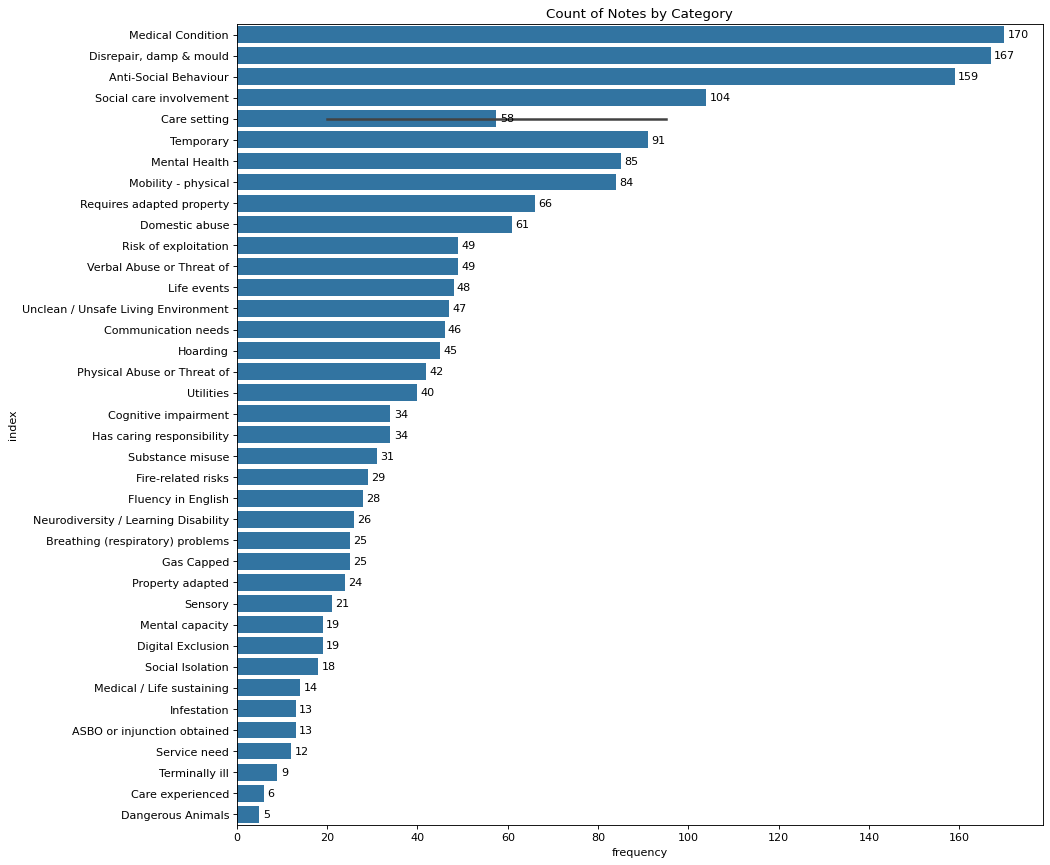

In [171]:
def analyze_category_distribution(df_labels):
    cat_value_counts = df_labels.sum(axis=0).reset_index(name="frequency").sort_values(by='frequency', ascending=False)

    # Calculate IRLbl per label (same as prep-gold-standard.ipynb)
    max_freq = cat_value_counts['frequency'].max()
    irlbl = max_freq / cat_value_counts['frequency']
    irlbl_df = pd.DataFrame({'label': cat_value_counts['index'].values, 'IRLbl': irlbl.values})
    display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))

    # Summary stats
    summary = pd.DataFrame({
        'Metric': ['MeanIR', 'MaxIR', 'CVIR'],
        'Value': [irlbl.mean(), irlbl.max(), irlbl.std() / irlbl.mean()]
    }).style.format({'Value': '{:.2f}'})
    display(summary)

    # Bar chart
    plt.figure(figsize=(13, 13), dpi=80)
    ax = sns.barplot(data=cat_value_counts, y='index', x='frequency', dodge=False)
    ax.bar_label(ax.containers[0], fmt='%.0f', padding=3) # type: ignore
    plt.title(f"Count of Notes by Category")
    plt.show()

analyze_category_distribution(df_labels)

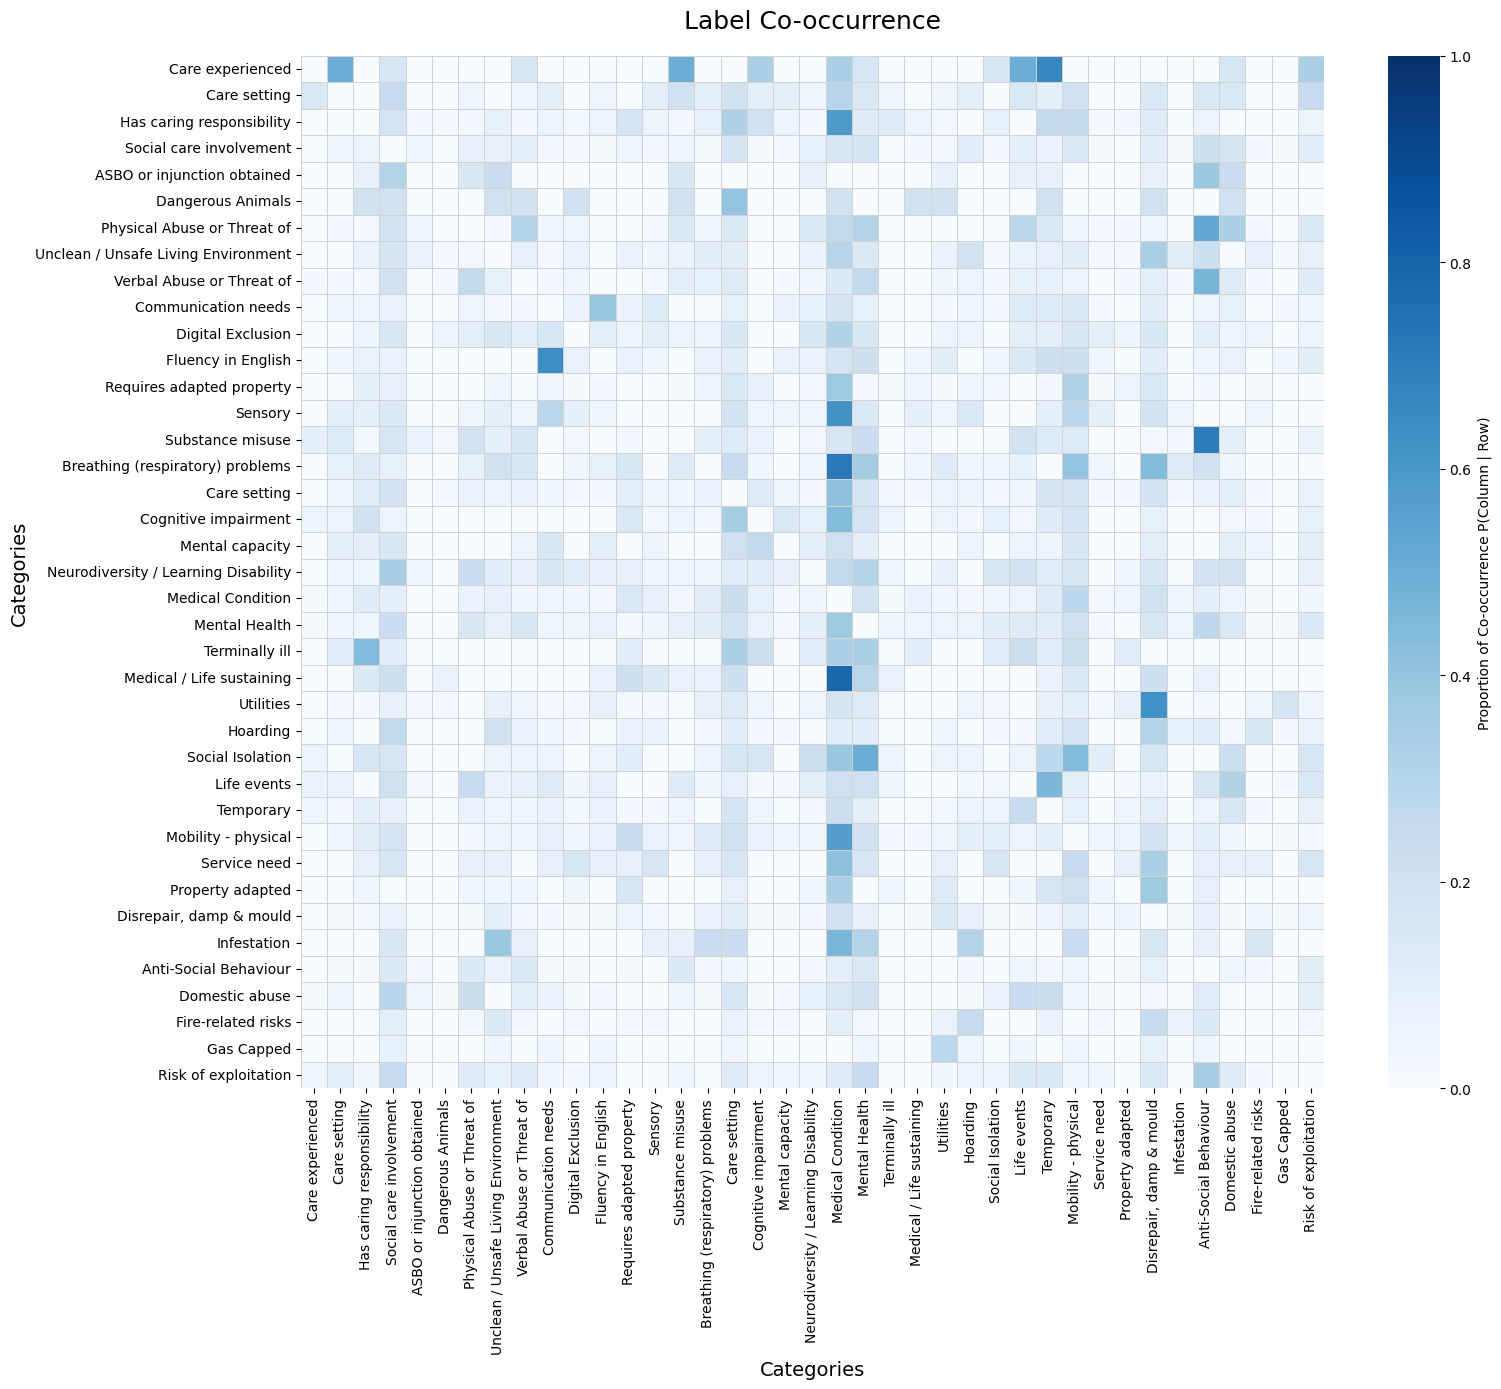

In [172]:
def show_co_occurence_heatmap(df_labels):
    # Calculate co-occurrence matrix by multiplying by transpose
    co_matrix = df_labels.T.dot(df_labels) 

    # Divide by class frequencies to yield conditional probability
    class_frequencies = np.diag(co_matrix) 
    normalized_matrix = co_matrix.div(class_frequencies, axis=0) 

    # Force diagonals to be 0s so they don't blow out the heatmap color scale
    normalized_matrix_arr = normalized_matrix.to_numpy(copy=True)
    np.fill_diagonal(normalized_matrix_arr, 0) 
    normalized_matrix = pd.DataFrame(normalized_matrix_arr, index=co_matrix.index, columns=co_matrix.columns)

    # Plot Heatmap
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        normalized_matrix, 
        cmap="Blues", 
        annot=False, 
        linewidths=0.5, 
        linecolor='lightgrey',
        vmin=0, vmax=1, 
        cbar_kws={'label': 'Proportion of Co-occurrence P(Column | Row)'}
    )

    plt.title("Label Co-occurrence", fontsize=18, pad=20)
    plt.xlabel("Categories", fontsize=14)
    plt.ylabel("Categories", fontsize=14)

    plt.tight_layout()
    plt.show()

show_co_occurence_heatmap(df_labels)

## Train/Test Split (80/20)

In [173]:
# Convert records into NumPy arrays for splitting
texts = np.array([r["text"] for r in records])

# Create labels
labels = df_labels.to_numpy()

# Train/Test split with Multi-Label Stratified Splitter (returns indexes)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE) # type: ignore
train_idx, val_idx = next(msss.split(texts, labels))

# Slice the data using the stratified indices
train_records = [records[i] for i in train_idx]
test_records = [records[i] for i in val_idx]

print(f"Stratified Train size: {len(train_records)} | Testing size: {len(test_records)}")

Stratified Train size: 920 | Testing size: 231


In [174]:
with open(TRAIN_OUTPUT_PATH.format(len(train_records)), "w", encoding="utf-8") as f:
    json.dump(train_records, f, indent=2)

with open(TEST_OUTPUT_PATH.format(len(test_records)), "w", encoding="utf-8") as f:
    json.dump(test_records, f, indent=2)